# Using BOSS Pixel Masks

## Learning Goals:
By the end of this tutorial you will be able to:
- Have a basic understanding of the available SDSS BOSS Spectra mask bits and how to use them to filter bad data.

## Introduction:
This tutorial focuses on working with BOSS Data and how to uses the various masks to flag and exclude bad data. It uses the AND_MASK, OR_MASK, and IVAR arrays to mask pixels. However, it should be noted that due to the nature of pipeline operations, not all unmasked pixels are without issues. 

***Caveat:*** In SDSS-V FPS era, outlier rejection is not applied during coadding individual exposures, so some deviant pixels (e.g. cosmic rays, bad sky line subtraction) might still be present in the final reduced spectra.

## Imports
This tutorial requires several commonly used python packages and several SDSS specific packages
- `pydl` for bitmask decoding and masking
- `astropy` for reading fits files and tables (and optionally used to download the supplemental files)
- `os` used for accessing environmental variables (optinal if not using `astropy` to download the supplemental files)
- `matplotlib` for plotting
- `numpy` for array operations

Missing packages can be installed via `pip install numpy matplotlib astropy pydl sdss-access`

**Note!**

If you already have `sdss_access` installed but have trouble with these file types, try upgrading to the latest version with `pip install --upgrade sdss-access sdss-tree`

In [1]:
from pydl.pydlutils import sdss
from astropy.utils.data import download_file
import os
from astropy.io import fits
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (10, 6)  # inches

import numpy as np

from sdss_access import Access, path

run2d = 'v6_2_1' # The Run2d version of the BOSS Pipeline used for DR20/ipl-4
release = 'dr20' 
sdss_path = path.Path(release=release, verbose=True) 
access = Access(release=release, verbose=True)

## Loading the BOSS Spectra
As shown in the other tutorials, `sdss_acess` can be used to retreive the boss spectra files ([specLite](https://data.sdss.org/datamodel/files/BOSS_SPECTRO_REDUX/RUN2D/spectra/lite/FIELD/MJD/specLite.html) or [specFull](https://data.sdss.org/datamodel/files/BOSS_SPECTRO_REDUX/RUN2D/spectra/full/FIELD/MJD/specFull.html)) and build their paths. There are 3 classes of SDSS-V coadd: daily, field epoch, and allepoch (custom coadds) which can all be accessed as demonstrated below. Some of the other tutorials go further in depth in to these different coadds. They also further elaborate on how to determine the MJDs and fieldIDs of your target. 

In [2]:
catalogid = 27021597842439106
mjd = 60095
fieldid = 101202

# Daily Spectra
specFile = access.full('specLite', run2d=run2d, fieldid=fieldid, mjd = mjd, catalogid=catalogid)

# Note: for the Field Epoch and Allepoch, some of the parameters differ (mjd might be different, and fieldids might be replaced with coadd=‘allepoch’ and obs added instead) 
#       depending on the target selected. Additionally, not all catalogids are in the allepoch coadds
# Field Epoch Spectra
# specFile = access.full('specLite_epoch', run2d=run2d, fieldid = fieldid, mjd = mjd, catalogid=catalogid)
# Allepoch Spectra
# specFile = access.full('specLite_coadd', run2d=run2d, coadd = 'allepoch', mjd = mjd, catalogid=catalogid, obs='apo')

if not access.exists('',full=specFile):
    access.remote()
    # Daily Spectra
    access.add('specLite', run2d=run2d, fieldid = fieldid, mjd = mjd, catalogid=catalogid)
    # Field Epoch Spectra
    #access.add('specLite_epoch', run2d=run2d, fieldid = fieldid, mjd = mjd, catalogid=catalogid)
    # Allepoch Spectra
    #access.add('specLite_coadd', run2d=run2d, coadd = 'allepoch', mjd = mjd, catalogid=catalogid)
    access.set_stream()
    access.commit()
    access.reset()
    specFile = access.full('specLite', run2d=run2d, fieldid=fieldid, mjd = mjd, catalogid=catalogid)

fits.info(specFile)

Filename: /Users/jdonor/sas/dr20/spectro/boss/redux/v6_2_1/spectra/daily/lite/101XXX/101202/60095/spec-101202-60095-27021597842439106.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  FLUX          1 PrimaryHDU     283   ()      
  1  COADD         1 BinTableHDU     34   4648R x 9C   [E, E, E, J, J, E, E, E, E]   
  2  SPALL         1 BinTableHDU    327   1R x 147C   [K, K, 3A, D, 17A, 32A, 6A, 6A, 20A, 17A, I, E, K, 11A, 41A, 10A, 10A, 10A, 30A, 19A, 69B, 16A, 5A, K, K, K, K, K, K, 29A, 5E, 5E, 25A, 5E, 5E, 5E, 5E, E, K, E, E, K, 4E, 3E, 2E, E, 3A, D, D, D, D, D, D, E, E, E, E, 32A, 29A, 23A, 23A, K, 26A, 26A, E, E, K, K, K, 68A, 3A, D, E, 14A, 14A, 14A, E, E, E, E, E, E, 5E, E, E, E, E, E, 14A, 14A, 5A, 5A, 5A, 5A, K, K, K, K, K, K, 5E, 5E, 5E, 5E, 5E, E, E, E, 6A, 19A, E, E, K, E, K, E, 24A, 10K, K, 10E, E, E, E, E, E, E, K, E, 10E, 10E, 10E, E, E, K, K, 6A, 19A, E, E, E, E, E, E, E, E, E, E]   
  3  ZALL          1 BinTableHDU    135   134R x 56C   [J, J, J, J

The full spectra contain added extensions with the individual exposures. Either these or the lite spectra can be used, as they are identical in the main extensions.  


In [3]:
catalogid = 27021597842439106
mjd = 60095
fieldid = 101202

# Daily Spectra
specFileFull = access.full('specFull', run2d=run2d, fieldid=fieldid, mjd = mjd, catalogid=catalogid)

# Note: for the Field Epoch and Allepoch, some of the parameters differ (mjd might be different, and fieldids might be replaced with coadd=‘allepoch’ and obs added instead) 
#       depending on the target selected. Additionally, not all catalogids are in the allepoch coadds
# Field Epoch Spectra
# specFileFull = access.full('specFull_epoch', run2d=run2d, fieldid = fieldid, mjd = mjd, catalogid=catalogid)
# Allepoch Spectra
# specFileFull = access.full('specFull_coadd', run2d=run2d, coadd = 'allepoch', mjd = mjd, catalogid=catalogid, obs='apo')


if not access.exists('',full=specFileFull):
    access.remote()
    # Daily Spectra
    access.add('specFull', run2d=run2d, fieldid = fieldid, mjd = mjd, catalogid=catalogid)
    # Field Epoch Spectra
    #access.add('specLite_epoch', run2d=run2d, fieldid = fieldid, mjd = mjd, catalogid=catalogid)
    # Allepoch Spectra
    #access.add('specLite_coadd', run2d=run2d, coadd = 'allepoch', mjd = mjd, catalogid=catalogid, obs='apo')
    access.set_stream()
    access.commit()
    access.reset()
fits.info(specFileFull)

Filename: /Users/jdonor/sas/dr20/spectro/boss/redux/v6_2_1/spectra/daily/full/101XXX/101202/60095/spec-101202-60095-27021597842439106.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  FLUX          1 PrimaryHDU     283   ()      
  1  COADD         1 BinTableHDU     34   4648R x 9C   [E, E, E, J, J, E, E, E, E]   
  2  SPALL         1 BinTableHDU    327   1R x 147C   [K, K, 3A, D, 17A, 32A, 6A, 6A, 20A, 17A, I, E, K, 11A, 41A, 10A, 10A, 10A, 30A, 19A, 69B, 16A, 5A, K, K, K, K, K, K, 29A, 5E, 5E, 25A, 5E, 5E, 5E, 5E, E, K, E, E, K, 4E, 3E, 2E, E, 3A, D, D, D, D, D, D, E, E, E, E, 32A, 29A, 23A, 23A, K, 26A, 26A, E, E, K, K, K, 68A, 3A, D, E, 14A, 14A, 14A, E, E, E, E, E, E, 5E, E, E, E, E, E, 14A, 14A, 5A, 5A, 5A, 5A, K, K, K, K, K, K, 5E, 5E, 5E, 5E, 5E, E, E, E, 6A, 19A, E, E, K, E, K, E, 24A, 10K, K, 10E, E, E, E, E, E, E, K, E, 10E, 10E, 10E, E, E, K, K, 6A, 19A, E, E, E, E, E, E, E, E, E, E]   
  3  ZALL          1 BinTableHDU    135   134R x 56C   [J, J, J, J

In [4]:
spectra = fits.getdata(specFile,1)

The wavelength in stored in log(lambda[Å]), and the noise is stored as IVAR, these can be converted as shown below

In [5]:
noise=np.zeros_like(spectra['IVAR'])
mask_ivar = spectra['IVAR'] < 1.0e-6
noise[~mask_ivar]=1./np.sqrt(spectra['IVAR'][~mask_ivar])
wave = np.power(10, spectra['LOGLAM'])

While not a pixel mask, the spAll extension contains the ZWARNING, which provides some information about quality:

In [6]:
spAll = fits.getdata(specFile,2)[0]
zwarn = sdss.sdss_flagname('ZWARNING', spAll['ZWARNING'],concat=True)
if zwarn == '':
    zwarn = 'None'
print(
    f"z: {spAll['Z']:.4f} ± {spAll['Z_ERR']:.4f}\n"
    f"class: {spAll['CLASS']} (subclass: {spAll['SUBCLASS']})\n"
    f"ZWARNING: {zwarn}"
)


z: 0.5163 ± 0.0001
class: QSO (subclass: BROADLINE)


### Plotting the Raw Unmasked Spectra

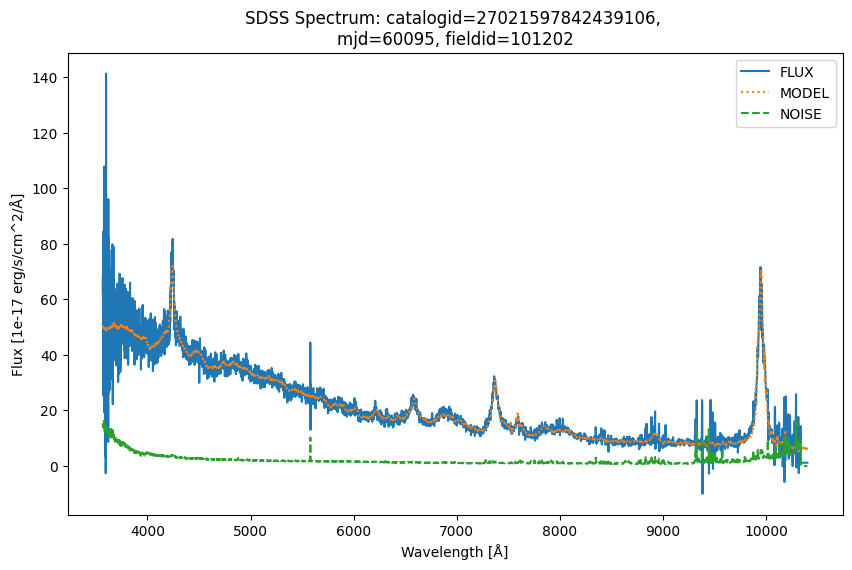

In [7]:
plt.figure()
plt.plot(wave,spectra['FLUX'], label='FLUX')
plt.plot(wave,spectra['MODEL'], label='MODEL',ls=':')
plt.plot(wave,noise, label='NOISE',ls ='--')
plt.legend()
plt.xlabel('Wavelength [Å]')
plt.ylabel('Flux [1e-17 erg/s/cm^2/Å]')
plt.title(f'SDSS Spectrum: catalogid={catalogid}, \nmjd={mjd}, fieldid={fieldid}')
plt.show()


### Plotting the smoothed Unmasked Spectra

In [8]:
def sdss_spec_smooth(loglam, flux, vdisp):
    # Smooth a spectrum to a given velocity dispersion (in km/s) - This is from the boss pipeline and is used to plot spectra for previews
    # loglam - logarithmic wavelength array
    # flux - flux array
    # vdisp - velocity dispersion in km/s
    # Returns smoothed flux array
    sflux=flux
    if vdisp > 1.0:
        nlambda= len(loglam)
        pixsize= np.abs(np.log(10.)*2.99792e+5*(loglam[nlambda-1]-loglam[0])/nlambda)
        smoothing= vdisp/pixsize    # pixels
        npix= int(4.0*np.ceil(smoothing))*2+3
        klam= np.arange(npix,dtype=float)-(npix-1.)/2.
        kernel= np.exp(-0.5*np.power((klam/smoothing),2))/np.sqrt(2.*np.pi)/smoothing
        kernel= kernel/np.sum(kernel)
        
        if(len(kernel) > len(flux)):
            sflux= flux
        else:
            sflux= np.convolve(flux,kernel,mode='same')
    else:
        sflux = flux
    return(sflux)

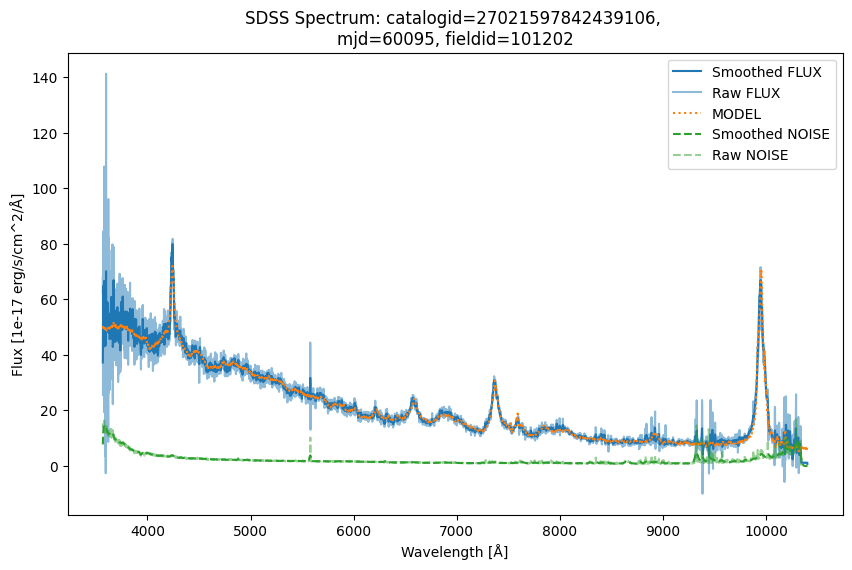

In [9]:
plt.figure()
plt.plot(wave,sdss_spec_smooth(spectra['LOGLAM'],spectra['FLUX'], 100), label='Smoothed FLUX', color='C0')
plt.plot(wave,spectra['FLUX'], alpha=.5, label='Raw FLUX', color='C0')
plt.plot(wave,spectra['MODEL'], label='MODEL',ls=':', color='C1')
plt.plot(wave,sdss_spec_smooth(spectra['LOGLAM'],noise, 400), label='Smoothed NOISE',ls ='--', color='C2')
plt.plot(wave,noise, alpha=.5, label='Raw NOISE',ls ='--', color='C2')
plt.legend()
plt.xlabel('Wavelength [Å]')
plt.ylabel('Flux [1e-17 erg/s/cm^2/Å]')
plt.title(f'SDSS Spectrum: catalogid={catalogid}, \nmjd={mjd}, fieldid={fieldid}')
plt.show()


## BOSS Spectra Pixel Masks
The BOSS spectra files (specFull and specLite) contain both AND_MASK and OR_MASK. These both use the same bit definitions, but are merged with logical AND or OR (respectively) for the individual exposures and red+blue cameras. For most cases, the average user will want to use AND_MASK since OR_MASK is likely too aggressive and will mask at pixels that still provide viable science, but in most of the following examples, OR_MASK is for better visualization with the larger number of masked pixels. 

The definitions of these bits are stored in the IDLUTILS GitHub product as "SPPIXMASK" and are explained in https://sdss.org/dr19/data_access/bitmasks/#SPPIXMASK. However, it should be noted that these bits do not necessarily mask every single bad pixel, but rather pixels that have known issues (with known causes).



In [10]:
#the latest version
#baseurl = 'https://raw.githubusercontent.com/sdss/idlutils/refs/heads/master/data/sdss/sdssMaskbits.par' 
#maskbitfile = download_file(baseurl, cache='update')

#the DR19/DR20 version
baseurl = 'https://raw.githubusercontent.com/sdss/idlutils/refs/tags/6.3.0/data/sdss/sdssMaskbits.par' 
maskbitfile = download_file(baseurl, cache='update')

#Pre-existing IDLutils install
#maskbitfile = os.path.join(os.getenv("IDLUTILS_DIR"),"data","sdss","sdssMaskbits.par")

_ = sdss.set_maskbits(maskbits_file=maskbitfile).get('SPPIXMASK')

<table style="font-size:18px; border-collapse:collapse;">
  <tr>
    <th style="border:1px solid; padding:6px;">Bit Name</th>
    <th style="border:1px solid; padding:6px;">Binary Digit</th>
    <th style="border:1px solid; padding:6px;">Description</th>
  </tr>
  <tr><td style="border:1px solid; padding:6px;">NOPLUG</td><td style="border:1px solid; padding:6px;">0</td><td style="border:1px solid; padding:6px;">Fiber not listed in plugmap file</td></tr>
  <tr><td style="border:1px solid; padding:6px;">BADTRACE</td><td style="border:1px solid; padding:6px;">1</td><td style="border:1px solid; padding:6px;">Bad trace from routine TRACE320CRUDE</td></tr>
  <tr><td style="border:1px solid; padding:6px;">BADFLAT</td><td style="border:1px solid; padding:6px;">2</td><td style="border:1px solid; padding:6px;">Low counts in fiberflat</td></tr>
  <tr><td style="border:1px solid; padding:6px;">BADARC</td><td style="border:1px solid; padding:6px;">3</td><td style="border:1px solid; padding:6px;">Bad arc solution</td></tr>
  <tr><td style="border:1px solid; padding:6px;">MANYBADCOLUMNS</td><td style="border:1px solid; padding:6px;">4</td><td style="border:1px solid; padding:6px;">More than 10% of pixels are bad columns</td></tr>
  <tr><td style="border:1px solid; padding:6px;">MANYREJECTED</td><td style="border:1px solid; padding:6px;">5</td><td style="border:1px solid; padding:6px;">More than 10% of pixels are rejected in extraction</td></tr>
  <tr><td style="border:1px solid; padding:6px;">LARGESHIFT</td><td style="border:1px solid; padding:6px;">6</td><td style="border:1px solid; padding:6px;">Large spatial shift between flat and object position</td></tr>
  <tr><td style="border:1px solid; padding:6px;">BADSKYFIBER</td><td style="border:1px solid; padding:6px;">7</td><td style="border:1px solid; padding:6px;">Sky fiber shows extreme residuals</td></tr>
  <tr><td style="border:1px solid; padding:6px;">NEARWHOPPER</td><td style="border:1px solid; padding:6px;">8</td><td style="border:1px solid; padding:6px;">DEPRECATED, no longer set as of BOSS DR9. Prior to DR9 meant within 2 fibers of a whopping fiber (exclusive)</td></tr>
  <tr><td style="border:1px solid; padding:6px;">WHOPPER</td><td style="border:1px solid; padding:6px;">9</td><td style="border:1px solid; padding:6px;">Whopping fiber, with a very bright source.</td></tr>
  <tr><td style="border:1px solid; padding:6px;">SMEARIMAGE</td><td style="border:1px solid; padding:6px;">10</td><td style="border:1px solid; padding:6px;">DEPRECATED. Prior to DR9 meant smear available for red and blue cameras</td></tr>
  <tr><td style="border:1px solid; padding:6px;">SMEARHIGHSN</td><td style="border:1px solid; padding:6px;">11</td><td style="border:1px solid; padding:6px;">DEPRECATED. Prior to DR9 meant S/N sufficient for full smear fit</td></tr>
  <tr><td style="border:1px solid; padding:6px;">SMEARMEDSN</td><td style="border:1px solid; padding:6px;">12</td><td style="border:1px solid; padding:6px;">DEPRECATED. Prior to DR9 meant S/N only sufficient for scaled median fit</td></tr>
  <tr><td style="border:1px solid; padding:6px;">NEARBADPIXEL</td><td style="border:1px solid; padding:6px;">16</td><td style="border:1px solid; padding:6px;">Bad pixel within 3 pixels of trace.</td></tr>
  <tr><td style="border:1px solid; padding:6px;">LOWFLAT</td><td style="border:1px solid; padding:6px;">17</td><td style="border:1px solid; padding:6px;">Flat field less than 0.5</td></tr>
  <tr><td style="border:1px solid; padding:6px;">FULLREJECT</td><td style="border:1px solid; padding:6px;">18</td><td style="border:1px solid; padding:6px;">Pixel fully rejected in extraction (INVVAR=0)</td></tr>
  <tr><td style="border:1px solid; padding:6px;">PARTIALREJECT</td><td style="border:1px solid; padding:6px;">19</td><td style="border:1px solid; padding:6px;">Some pixels rejected in extraction</td></tr>
  <tr><td style="border:1px solid; padding:6px;">SCATTEREDLIGHT</td><td style="border:1px solid; padding:6px;">20</td><td style="border:1px solid; padding:6px;">Scattered light significant</td></tr>
  <tr><td style="border:1px solid; padding:6px;">CROSSTALK</td><td style="border:1px solid; padding:6px;">21</td><td style="border:1px solid; padding:6px;">Cross-talk significant</td></tr>
  <tr><td style="border:1px solid; padding:6px;">NOSKY</td><td style="border:1px solid; padding:6px;">22</td><td style="border:1px solid; padding:6px;">Sky level unknown at this wavelength (INVVAR=0)</td></tr>
  <tr><td style="border:1px solid; padding:6px;">BRIGHTSKY</td><td style="border:1px solid; padding:6px;">23</td><td style="border:1px solid; padding:6px;">Sky level &gt; flux + 10*(flux_err) AND sky &gt; 1.25 * median(sky,99 pixels)</td></tr>
  <tr><td style="border:1px solid; padding:6px;">NODATA</td><td style="border:1px solid; padding:6px;">24</td><td style="border:1px solid; padding:6px;">DEPRECATED, should be ignored in favor of flagging on INVVAR=0. Prior to DR9 meant no data available in combine B-spline (INVVAR=0)</td></tr>
  <tr><td style="border:1px solid; padding:6px;">COMBINEREJ</td><td style="border:1px solid; padding:6px;">25</td><td style="border:1px solid; padding:6px;">Rejected in combine B-spline</td></tr>
  <tr><td style="border:1px solid; padding:6px;">BADFLUXFACTOR</td><td style="border:1px solid; padding:6px;">26</td><td style="border:1px solid; padding:6px;">Low flux-calibration or flux-correction factor</td></tr>
  <tr><td style="border:1px solid; padding:6px;">BADSKYCHI</td><td style="border:1px solid; padding:6px;">27</td><td style="border:1px solid; padding:6px;">Relative χ2 &gt; 3 in sky residuals at this wavelength</td></tr>
  <tr><td style="border:1px solid; padding:6px;">REDMONSTER</td><td style="border:1px solid; padding:6px;">28</td><td style="border:1px solid; padding:6px;">Contiguous region of bad χ2 in sky residuals (with threshold of relative χ2 &gt; 3).</td></tr>
</table>


## Decoding the Bits
The Bits can be decoded using `pydl`'s `pydl.pydlutils.sdss` Module. It contains codes to get the bit names from a value, or get a bit value from a name:
- `sdss_flagname(flagname, flagvalue[, concat])`: Return a list of flag names corresponding to the values.
- `sdss_flagval(flagname, bitname)`: Convert bitmask names into values.

In [11]:
for bit in set(spectra['OR_MASK']):
    print(f"{bit}: {sdss.sdss_flagname('SPPIXMASK',bit)} \tcount:{sum(spectra['OR_MASK'] == bit)}")

0: [] 	count:3515
524288: ['PARTIALREJECT'] 	count:104
83886080: ['NODATA', 'BADFLUXFACTOR'] 	count:454
589824: ['NEARBADPIXEL', 'PARTIALREJECT'] 	count:63
851968: ['NEARBADPIXEL', 'FULLREJECT', 'PARTIALREJECT'] 	count:38
88211456: ['LOWFLAT', 'NOSKY', 'NODATA', 'BADFLUXFACTOR'] 	count:2
88080384: ['NOSKY', 'NODATA', 'BADFLUXFACTOR'] 	count:6
71303168: ['NOSKY', 'BADFLUXFACTOR'] 	count:332
71827456: ['PARTIALREJECT', 'NOSKY', 'BADFLUXFACTOR'] 	count:6
71892992: ['NEARBADPIXEL', 'PARTIALREJECT', 'NOSKY', 'BADFLUXFACTOR'] 	count:10
72155136: ['NEARBADPIXEL', 'FULLREJECT', 'PARTIALREJECT', 'NOSKY', 'BADFLUXFACTOR'] 	count:8
205520896: ['NOSKY', 'BADFLUXFACTOR', 'BADSKYCHI'] 	count:2
201326592: ['BADFLUXFACTOR', 'BADSKYCHI'] 	count:8
67108864: ['BADFLUXFACTOR'] 	count:2
134217728: ['BADSKYCHI'] 	count:6
167772160: ['COMBINEREJ', 'BADSKYCHI'] 	count:2
33554432: ['COMBINEREJ'] 	count:34
16777216: ['NODATA'] 	count:2
218103808: ['NODATA', 'BADFLUXFACTOR', 'BADSKYCHI'] 	count:2
71368704: ['NEA

### Masking All Flagged Pixels
If you want to mask all Flagged pixels, you can just mask all pixels where requested mask is not equal to 0.

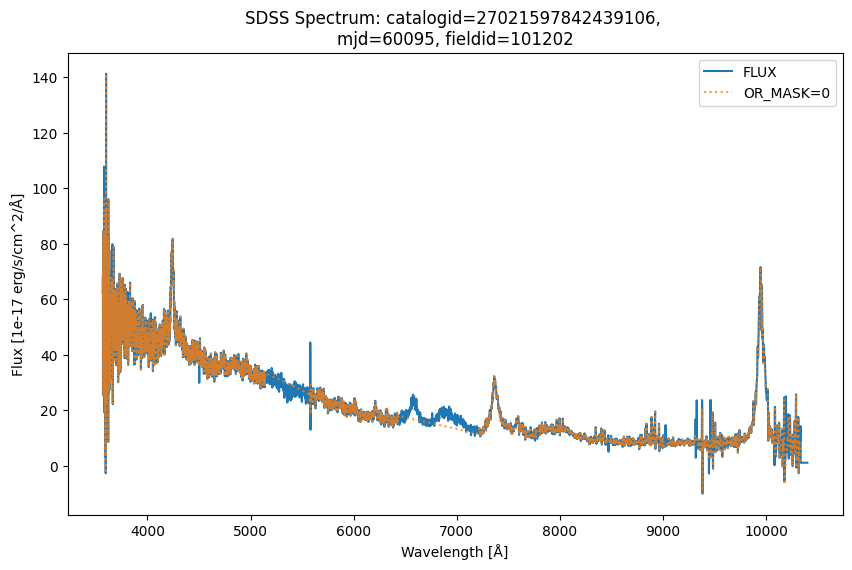

In [12]:
plt.figure()
plt.plot(wave,spectra['FLUX'], label='FLUX')
mask = spectra['OR_MASK'] != 0
plt.plot(wave[~mask],spectra['FLUX'][~mask],ls= ':',alpha=.8, label='OR_MASK=0')
plt.legend()
plt.xlabel('Wavelength [Å]')
plt.ylabel('Flux [1e-17 erg/s/cm^2/Å]')
plt.title(f'SDSS Spectrum: catalogid={catalogid}, \nmjd={mjd}, fieldid={fieldid}')
plt.show()


### Masking Only Indicated Bits
If you only want to mask certain bits, you can do so by using bitwise operations. For example, to mask out pixels flagged as NOSKY or NODATA:

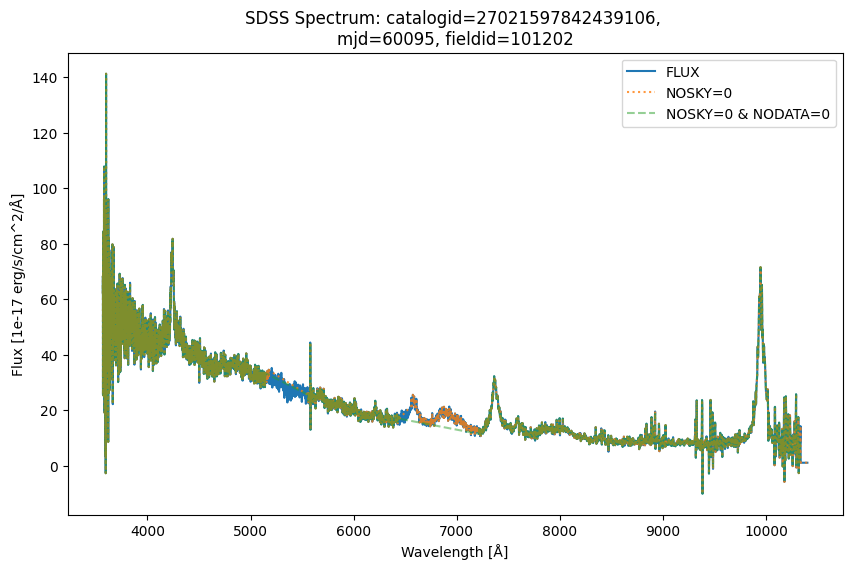

In [13]:
plt.figure()
plt.plot(wave,spectra['FLUX'], label='FLUX')
mask = (spectra['OR_MASK'].astype(np.uint64) & (sdss.sdss_flagval('SPPIXMASK','NOSKY'))) != 0
plt.plot(wave[~mask],spectra['FLUX'][~mask],ls= ':',alpha=.8, label='NOSKY=0')

mask = ((spectra['OR_MASK'].astype(np.uint64)) & (sdss.sdss_flagval('SPPIXMASK','NOSKY') | sdss.sdss_flagval('SPPIXMASK','NODATA'))) != 0
plt.plot(wave[~mask],spectra['FLUX'][~mask],ls= '--',alpha=.5, label='NOSKY=0 & NODATA=0')

plt.legend()
plt.xlabel('Wavelength [Å]')
plt.ylabel('Flux [1e-17 erg/s/cm^2/Å]')
plt.title(f'SDSS Spectrum: catalogid={catalogid}, \nmjd={mjd}, fieldid={fieldid}')
plt.show()


## Using IVAR as a mask
In addition to the AND_MASK and OR_MASK, the IVAR values can be used as a mask, but it is a much more conservative mask (masks fewer pixels) than the AND_MASK or OR_MASK:

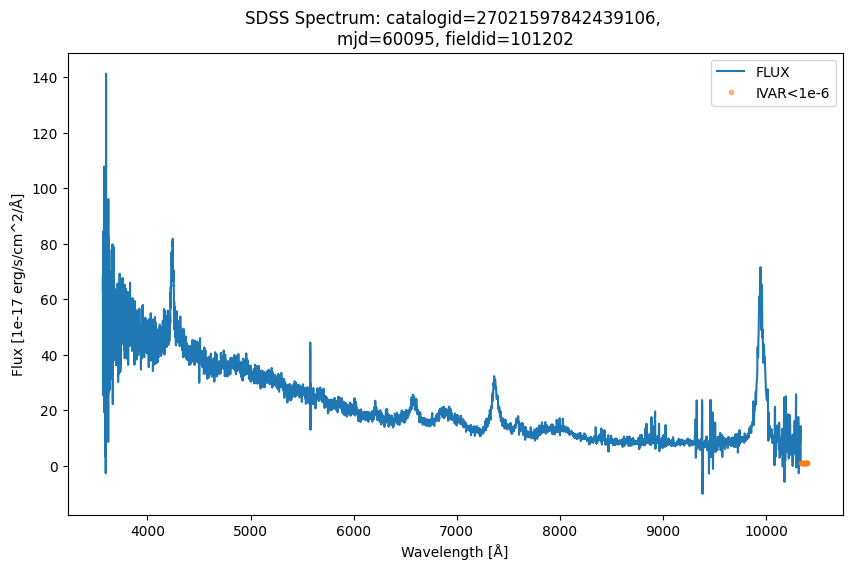

In [14]:
plt.figure()
plt.plot(wave,spectra['FLUX'], label='FLUX')
mask_ivar = spectra['IVAR'] < 1.0e-6
plt.plot(wave[mask_ivar],spectra['FLUX'][mask_ivar], ls = '', marker = '.',label='IVAR<1e-6', alpha=.5)
plt.legend()
plt.xlabel('Wavelength [Å]')
plt.ylabel('Flux [1e-17 erg/s/cm^2/Å]')
plt.title(f'SDSS Spectrum: catalogid={catalogid}, \nmjd={mjd}, fieldid={fieldid}')
plt.show()


## Trimming the Ends of the Spectra
Due to the nature of the model fitting (for flux calibration) and spectra tracing in an automated pipeline, the ends of the spectra naturally exhibit increased noise and less reliable flux calibration. Historical guidance for this has been to trim the ends of the spectra to ~3900Å to ~10,000Å, but the exact values depend on the Signal-to-noise requirements of the science. The preview plots produced by the pipeline are trim at 3700Å to 10,000Å

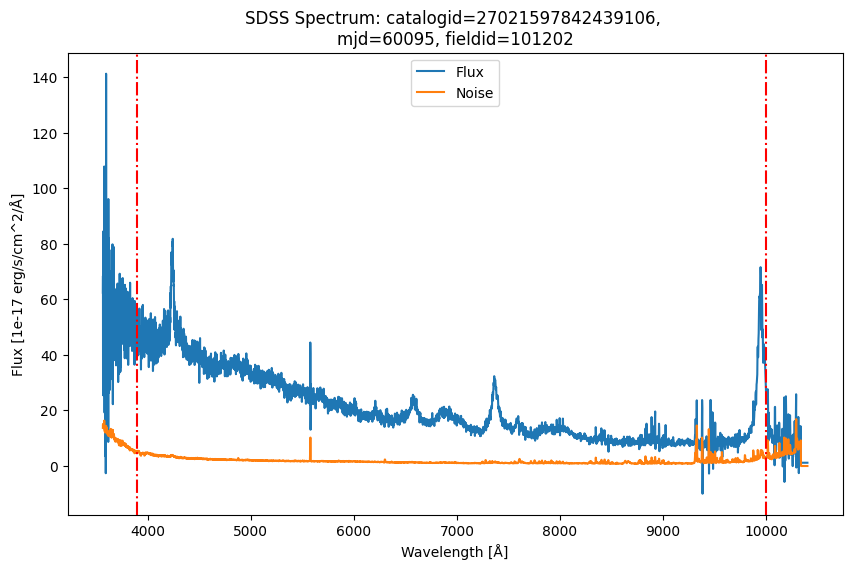

In [15]:
plt.figure()
plt.plot(wave,spectra['FLUX'], label='Flux')
plt.plot(wave, noise, label ='Noise')
plt.axvline(3900, color='r',ls ='-.')
plt.axvline(10000, color='r',ls ='-.')
plt.legend()
plt.xlabel('Wavelength [Å]')
plt.ylabel('Flux [1e-17 erg/s/cm^2/Å]')
plt.title(f'SDSS Spectrum: catalogid={catalogid}, \nmjd={mjd}, fieldid={fieldid}')
plt.show()


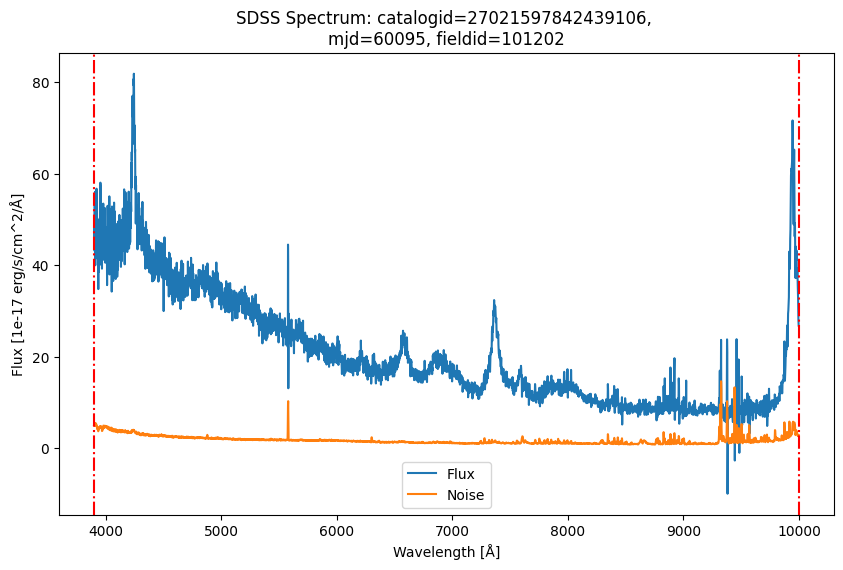

In [16]:
plt.figure()
wave_mask = (wave > 3900) & ( wave < 10000)
plt.plot(wave[wave_mask],spectra['FLUX'][wave_mask], label='Flux')
plt.plot(wave[wave_mask], noise[wave_mask], label ='Noise')
plt.axvline(3900, color='r',ls ='-.')
plt.axvline(10000, color='r',ls ='-.')
plt.legend()
plt.xlabel('Wavelength [Å]')
plt.ylabel('Flux [1e-17 erg/s/cm^2/Å]')
plt.title(f'SDSS Spectrum: catalogid={catalogid}, \nmjd={mjd}, fieldid={fieldid}')
plt.show()

## Merging all mask conditions
The various masks discussed above can be merged (using logical OR/AND) and applied to mask the spectra. Below is an example of this using the AND_MASK


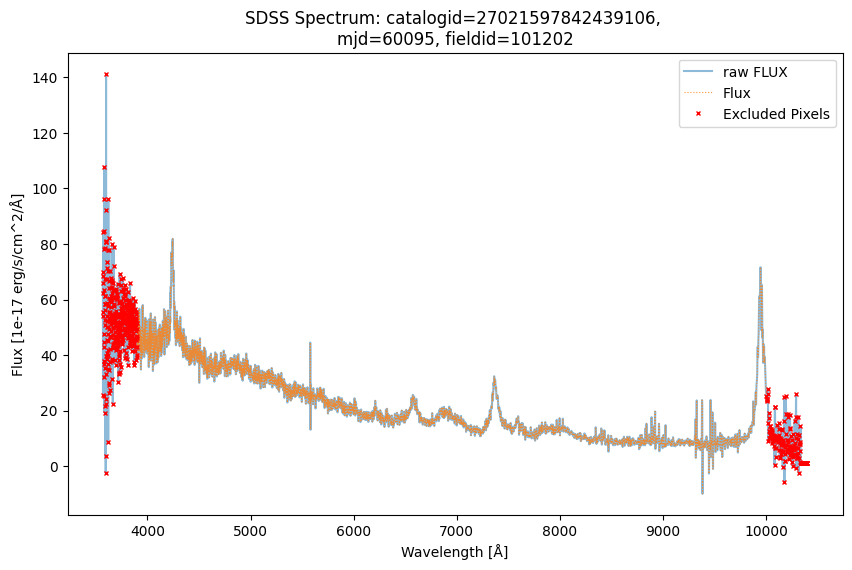

In [17]:
plt.figure()
plt.plot(wave,spectra['FLUX'], label='raw FLUX', alpha=.5,lw=1.5)
mask = (spectra['AND_MASK'] != 0) | (spectra['IVAR'] < 1.0e-6) | (wave < 3900) | ( wave > 10000)
mflux = np.copy(spectra['FLUX'])
mflux[mask] = np.nan
plt.plot(wave,mflux,ls= ':',alpha=.8, label='Flux',lw=.8)
plt.plot(wave[mask],spectra['FLUX'][mask],ls= '',label='Excluded Pixels', marker = 'x', color='r',ms=3)

plt.legend()
plt.xlabel('Wavelength [Å]')
plt.ylabel('Flux [1e-17 erg/s/cm^2/Å]')
plt.title(f'SDSS Spectrum: catalogid={catalogid}, \nmjd={mjd}, fieldid={fieldid}')
plt.show()

Below is similar to the above example, but using the OR_MASK instead. 

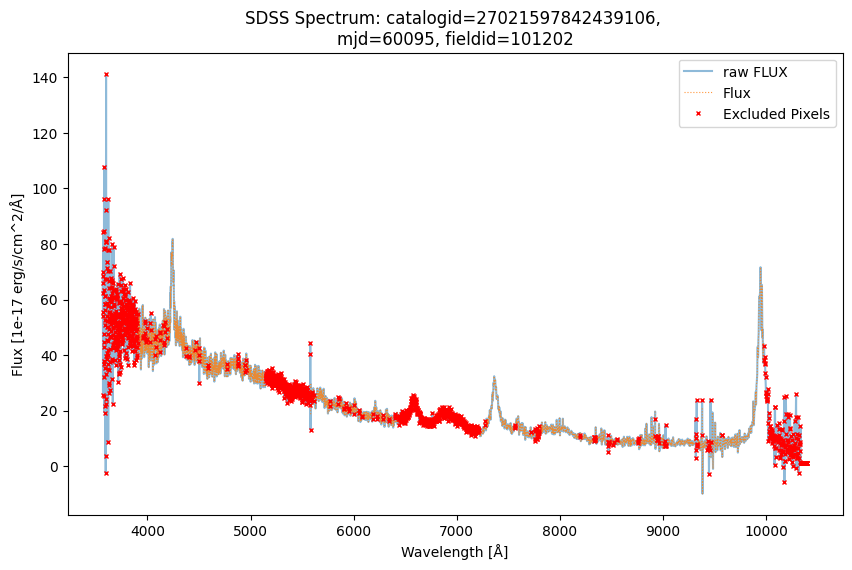

In [18]:
plt.figure()
plt.plot(wave,spectra['FLUX'], label='raw FLUX', alpha=.5,lw=1.5)
mask = (spectra['OR_MASK'] != 0) | (spectra['IVAR'] < 1.0e-6) | (wave < 3900) | ( wave > 10000)
mflux = np.copy(spectra['FLUX'])
mflux[mask] = np.nan
plt.plot(wave,mflux,ls= ':',alpha=.8, label='Flux',lw=.8)
plt.plot(wave[mask],spectra['FLUX'][mask],ls= '',label='Excluded Pixels', marker = 'x', color='r',ms=3)

plt.legend()
plt.xlabel('Wavelength [Å]')
plt.ylabel('Flux [1e-17 erg/s/cm^2/Å]')
plt.title(f'SDSS Spectrum: catalogid={catalogid}, \nmjd={mjd}, fieldid={fieldid}')
plt.show()

If you want to mask the with the AND_MASK mask plus exclude some of the pixels masked by the OR_MASK, you can join them together as show below, where we mask the AND_MASK + pixels with either BADSKYCHI or COMBINEREJ set in the OR_MASK

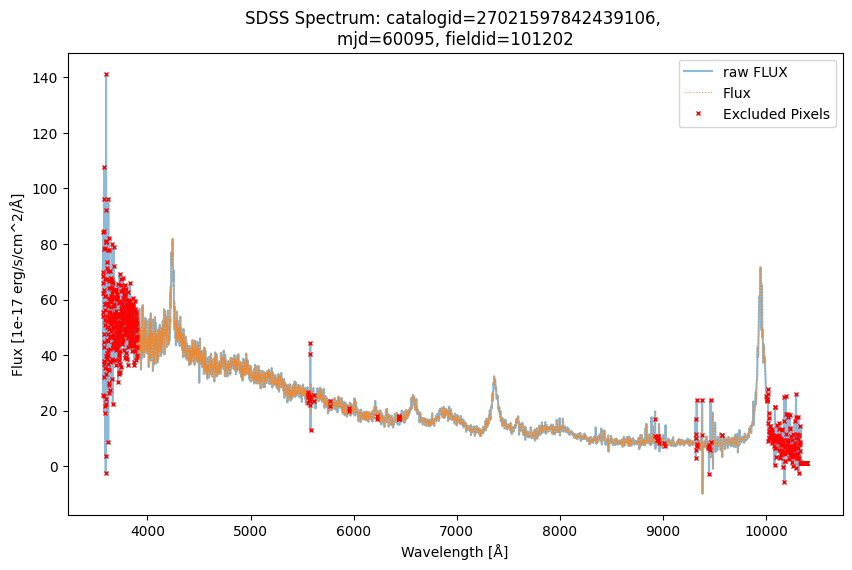

In [19]:
plt.figure()
plt.plot(wave,spectra['FLUX'], label='raw FLUX', alpha=.5,lw=1.5)
mask = (spectra['AND_MASK'] != 0) | (spectra['IVAR'] < 1.0e-6) | (wave < 3900) | ( wave > 10000)
mask2 = (spectra['OR_MASK'].astype(np.uint64) & (sdss.sdss_flagval('SPPIXMASK','BADSKYCHI') | 
                                                 sdss.sdss_flagval('SPPIXMASK','COMBINEREJ'))) != 0
mask = mask | mask2
mflux = np.copy(spectra['FLUX'])
mflux[mask] = np.nan
plt.plot(wave,mflux,ls= ':',alpha=.8, label='Flux',lw=.8)
plt.plot(wave[mask],spectra['FLUX'][mask],ls= '',label='Excluded Pixels', marker = 'x', color='r',ms=3)

plt.legend()
plt.xlabel('Wavelength [Å]')
plt.ylabel('Flux [1e-17 erg/s/cm^2/Å]')
plt.title(f'SDSS Spectrum: catalogid={catalogid}, \nmjd={mjd}, fieldid={fieldid}')
plt.show()

## About this notebook
This notebook was created to illustrate using the different masks available for use with BOSS data.

**Authors:** Sean Morrison

**Last Update:** 2026 Jan 27

If you use astropy for published research, please cite the authors. Follow this link for more information about citing astropy: [Citing `astropy`](https://www.astropy.org/acknowledging.html) 

And of course please [cite](https://sdss.org/collaboration/citing-sdss/) SDSS when you use our data.